In [1]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

Gürültülü foto boyut: (614, 617, 3)
Karanlık foto boyut: (340, 357, 3)


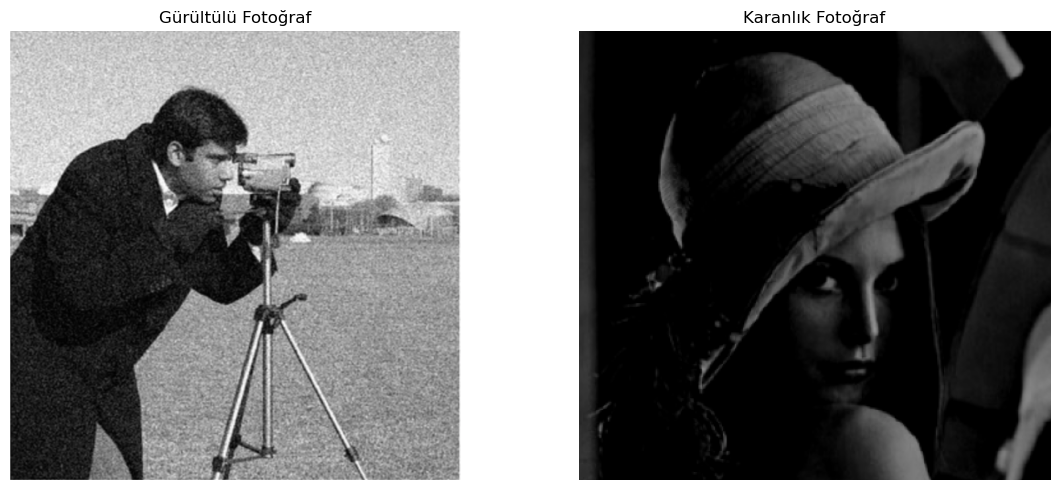

In [2]:
img_gurultulu=cv2.imread("fotograflar/gurultulu_foto.jpg")
img_karanlik2=cv2.imread("fotograflar/karanlik_foto2.jpg")

print("Gürültülü foto boyut:",img_gurultulu.shape)
print("Karanlık foto boyut:",img_karanlik2.shape)

gray_gurultulu=cv2.cvtColor(img_gurultulu,cv2.COLOR_BGR2GRAY)
gray_karanlik2=cv2.cvtColor(img_karanlik2,cv2.COLOR_BGR2GRAY)

fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].imshow(cv2.cvtColor(img_gurultulu,cv2.COLOR_BGR2RGB))
axes[0].set_title("Gürültülü Fotoğraf")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(img_karanlik2,cv2.COLOR_BGR2RGB))
axes[1].set_title("Karanlık Fotoğraf")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [3]:
def temel_metrikler(gray_img):
    return {
        "brightness": round(float(np.mean(gray_img)), 2),
        "contrast": round(float(np.std(gray_img)), 2),
        "blur_score": round(float(cv2.Laplacian(gray_img, cv2.CV_64F).var()), 2)
    }

gurultulu_sonuc = temel_metrikler(gray_gurultulu)
karanlik_sonuc = temel_metrikler(gray_karanlik2)

print(f"Gürültülü Foto  -> Brightness: {gurultulu_sonuc['brightness']}, Contrast: {gurultulu_sonuc['contrast']}, Blur Score: {gurultulu_sonuc['blur_score']}")
print(f"Karanlık Foto   -> Brightness: {karanlik_sonuc['brightness']}, Contrast: {karanlik_sonuc['contrast']}, Blur Score: {karanlik_sonuc['blur_score']}")

Gürültülü Foto  -> Brightness: 129.07, Contrast: 72.5, Blur Score: 268.48
Karanlık Foto   -> Brightness: 20.22, Contrast: 33.14, Blur Score: 64.45


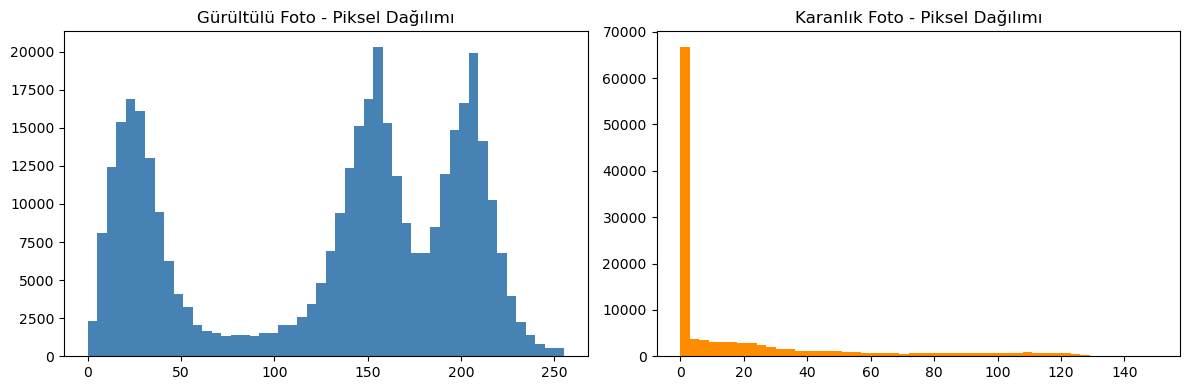

In [4]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].hist(gray_gurultulu.ravel(),bins=50,color="steelblue")
axes[0].set_title("Gürültülü Foto - Piksel Dağılımı")
axes[1].hist(gray_karanlik2.ravel(),bins=50,color="darkorange")
axes[1].set_title("Karanlık Foto - Piksel Dağılımı")
plt.tight_layout()
plt.show()

In [5]:
def homojen_bolge_gurultusu(gray_img, y1, y2, x1, x2):
    patch = gray_img[y1:y2, x1:x2]
    return np.std(patch)
    
y1, y2, x1, x2 =100,200,10,40

print(f"Gürültülü foto - düz bölge gürültüsü: {homojen_bolge_gurultusu(gray_gurultulu, y1, y2, x1, x2):.2f}")

Gürültülü foto - düz bölge gürültüsü: 10.28


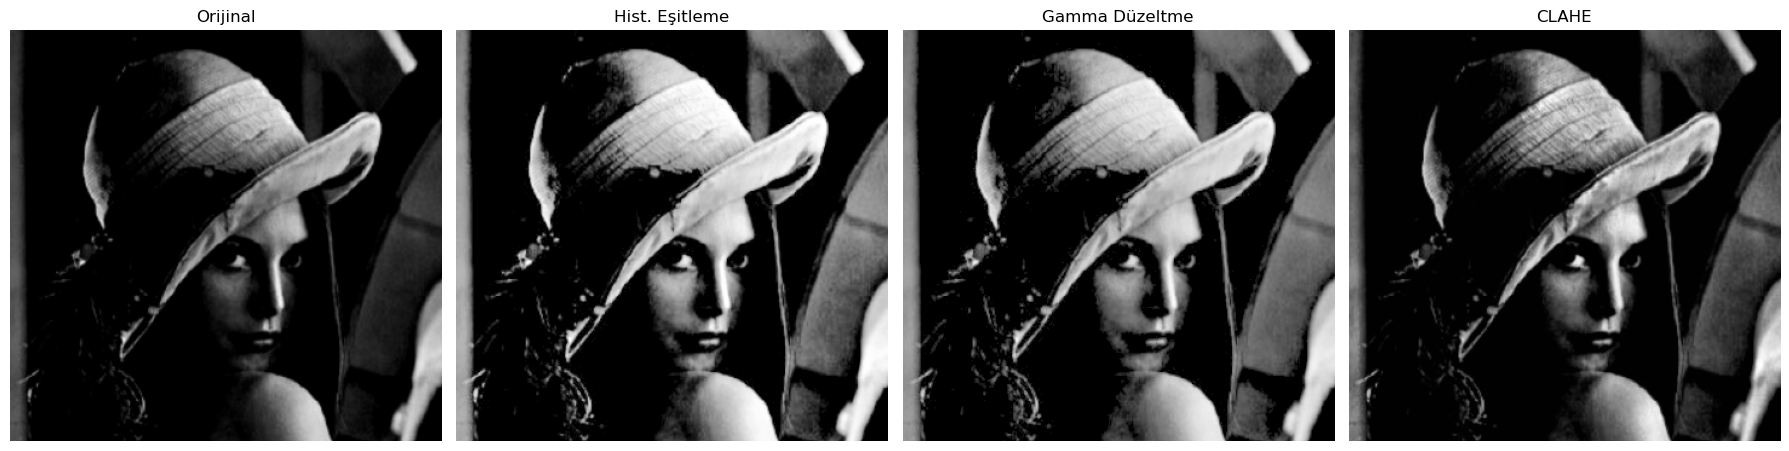

In [6]:
#Histogram Eşitleme
eq_karanlik2=cv2.equalizeHist(gray_karanlik2)

#Gamma Düzeltmesi
def gamma_duzeltme(img,gamma=2.2):
    inv_gamma=1.0/gamma
    tablo = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img,tablo)

gamma_karanlik2=gamma_duzeltme(gray_karanlik2,gamma=2.2)

#CLAHE
clahe=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
clahe_karanlik2=clahe.apply(gray_karanlik2)

fig,axes=plt.subplots(1,4,figsize=(18,5))
axes[0].imshow(gray_karanlik2,cmap="gray"); axes[0].set_title("Orijinal");axes[0].axis("off")
axes[1].imshow(eq_karanlik2,cmap="gray");axes[1].set_title("Hist. Eşitleme");axes[1].axis("off")
axes[2].imshow(gamma_karanlik2,cmap="gray");axes[2].set_title("Gamma Düzeltme");axes[2].axis("off")
axes[3].imshow(clahe_karanlik2,cmap="gray");axes[3].set_title("CLAHE");axes[3].axis("off")
plt.tight_layout()

In [7]:
y1b, y2b, x1b, x2b = 100, 200, 10, 40

print("\n===== KARANLIK FOTO: BLUR SCORE vs GÜRÜLTÜ =====")
for isim, img in [("Orijinal", gray_karanlik2), ("Hist. Eşitleme", eq_karanlik2),
                   ("Gamma Düzeltme", gamma_karanlik2), ("CLAHE", clahe_karanlik2)]:
    blur = cv2.Laplacian(img, cv2.CV_64F).var()
    gurultu = homojen_bolge_gurultusu(img, y1b, y2b, x1b, x2b)
    print(f"{isim:<18} Blur Score: {blur:>10.2f}   Gürültü: {gurultu:>8.2f}")


===== KARANLIK FOTO: BLUR SCORE vs GÜRÜLTÜ =====
Orijinal           Blur Score:      64.45   Gürültü:     5.53
Hist. Eşitleme     Blur Score:     551.77   Gürültü:    28.53
Gamma Düzeltme     Blur Score:     310.04   Gürültü:    22.19
CLAHE              Blur Score:     174.20   Gürültü:     8.98


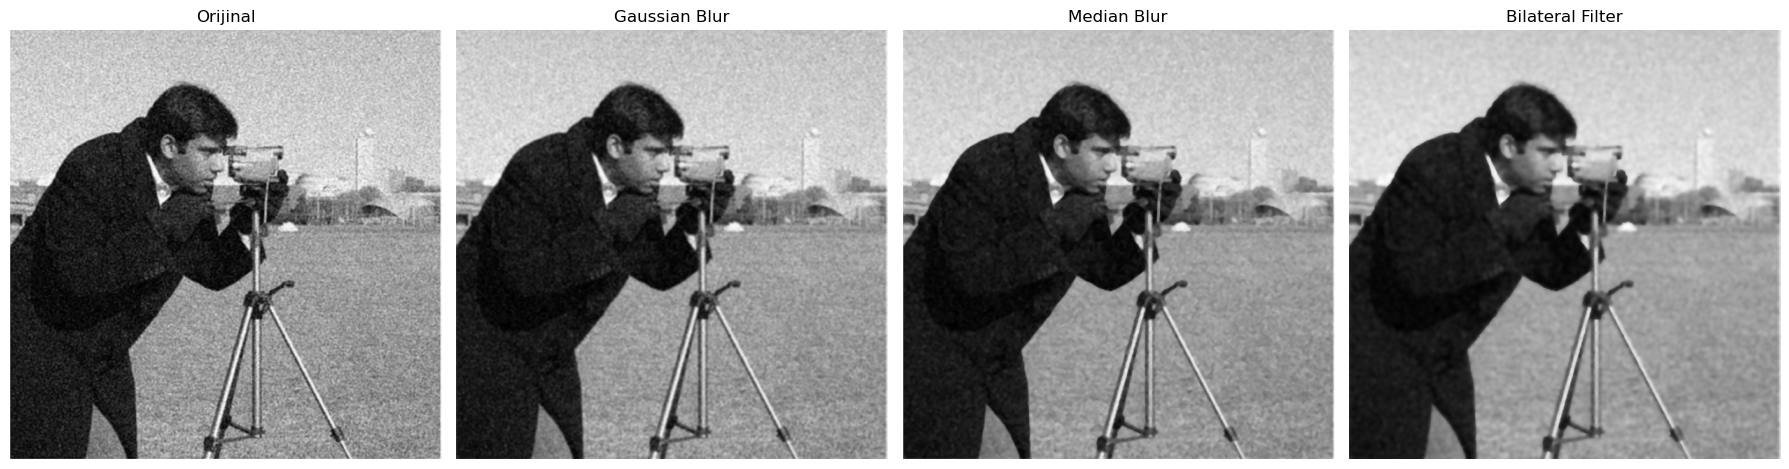


===== GÜRÜLTÜLÜ FOTO: BLUR SCORE vs GÜRÜLTÜ =====
Orijinal     Blur Score:     268.48   Gürültü:    10.28
Gaussian     Blur Score:      46.85   Gürültü:     7.15
Median       Blur Score:      99.38   Gürültü:     5.94
Bilateral    Blur Score:      26.24   Gürültü:     4.63


In [8]:
gaussian_gurultulu = cv2.GaussianBlur(gray_gurultulu, (5, 5), 0)
median_gurultulu = cv2.medianBlur(gray_gurultulu, 5)
bilateral_gurultulu = cv2.bilateralFilter(gray_gurultulu, d=9, sigmaColor=75, sigmaSpace=75)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(gray_gurultulu, cmap="gray"); axes[0].set_title("Orijinal"); axes[0].axis("off")
axes[1].imshow(gaussian_gurultulu, cmap="gray"); axes[1].set_title("Gaussian Blur"); axes[1].axis("off")
axes[2].imshow(median_gurultulu, cmap="gray"); axes[2].set_title("Median Blur"); axes[2].axis("off")
axes[3].imshow(bilateral_gurultulu, cmap="gray"); axes[3].set_title("Bilateral Filter"); axes[3].axis("off")
plt.tight_layout()
plt.show()

print("\n===== GÜRÜLTÜLÜ FOTO: BLUR SCORE vs GÜRÜLTÜ =====")
for isim, img in [("Orijinal", gray_gurultulu), ("Gaussian", gaussian_gurultulu),
                   ("Median", median_gurultulu), ("Bilateral", bilateral_gurultulu)]:
    blur = cv2.Laplacian(img, cv2.CV_64F).var()
    gurultu = homojen_bolge_gurultusu(img, y1b, y2b, x1b, x2b)
    print(f"{isim:<12} Blur Score: {blur:>10.2f}   Gürültü: {gurultu:>8.2f}")

In [9]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import pandas as pd

img_referans=cv2.imread("fotograflar/gurultulu_referans.jpg")
gray_referans=cv2.cvtColor(img_referans,cv2.COLOR_BGR2GRAY)

if gray_referans.shape!=gray_gurultulu.shape:
    h=min(gray_referans.shape[0],gray_gurultulu.shape[0])
    w=min(gray_referans.shape[1],gray_gurultulu.shape[1])
    gray_referans=cv2.resize(gray_referans,(w,h))
    gray_gurultulu=cv2.resize(gray_gurultulu,(w,h))

In [10]:
baseline_psnr=psnr(gray_referans,gray_gurultulu)
baseline_ssim=ssim(gray_referans,gray_gurultulu)
print(f"İşlem yapılmamış gürültülü foto -> PSNR: {baseline_psnr:.2f} dB, SSIM: {baseline_ssim:.4f}")
print("Her yöntemin bunu geçmesi lazım")

İşlem yapılmamış gürültülü foto -> PSNR: 21.86 dB, SSIM: 0.4326
Her yöntemin bunu geçmesi lazım


In [11]:
gaussian_dn=cv2.GaussianBlur(gray_gurultulu,(5,5),0)
median_dn=cv2.medianBlur(gray_gurultulu,5)
bilateral_dn=cv2.bilateralFilter(gray_gurultulu,d=9,sigmaColor=75,sigmaSpace=75)
nlm_dn = cv2.fastNlMeansDenoising(gray_gurultulu, None, h=10, 
                                    templateWindowSize=7, searchWindowSize=21)


In [12]:
yontemler={
    "Orijinal":gray_gurultulu,
    "Gaussian Blur":gaussian_dn,
    "Median Blur":median_dn,
    "Bilateral Filter":bilateral_dn,
    "Non-Local Means":nlm_dn,
}

sonuclar=[]
for isim,img in yontemler.items():
    sonuclar.append({
        "yontem":isim,
        "psnr":psnr(gray_referans,img),
        "ssim":ssim(gray_referans,img),
        "blur_score":cv2.Laplacian(img,cv2.CV_64F).var(),
        "gurultu":homojen_bolge_gurultusu(img,100,200,10,40)
    })

df_denoise=pd.DataFrame(sonuclar)
print("\n===== DENOISE YÖNTEMLERİ KARŞILAŞTIRMASI =====")
print(df_denoise.to_string(index=False))

en_iyi = df_denoise.loc[df_denoise["psnr"].idxmax()]
print(f"\n En iyi yöntem (PSNR'a göre): {en_iyi['yontem']} (PSNR: {en_iyi['psnr']:.2f} dB)")  


===== DENOISE YÖNTEMLERİ KARŞILAŞTIRMASI =====
          yontem      psnr     ssim  blur_score  gurultu
        Orijinal 21.858271 0.432613  203.058603 9.240930
   Gaussian Blur 23.048935 0.577219   40.515792 6.762968
     Median Blur 23.084963 0.639178   90.050443 5.723810
Bilateral Filter 23.898221 0.710539   22.228375 4.537947
 Non-Local Means 22.791976 0.714624   76.878107 3.503417

 En iyi yöntem (PSNR'a göre): Bilateral Filter (PSNR: 23.90 dB)


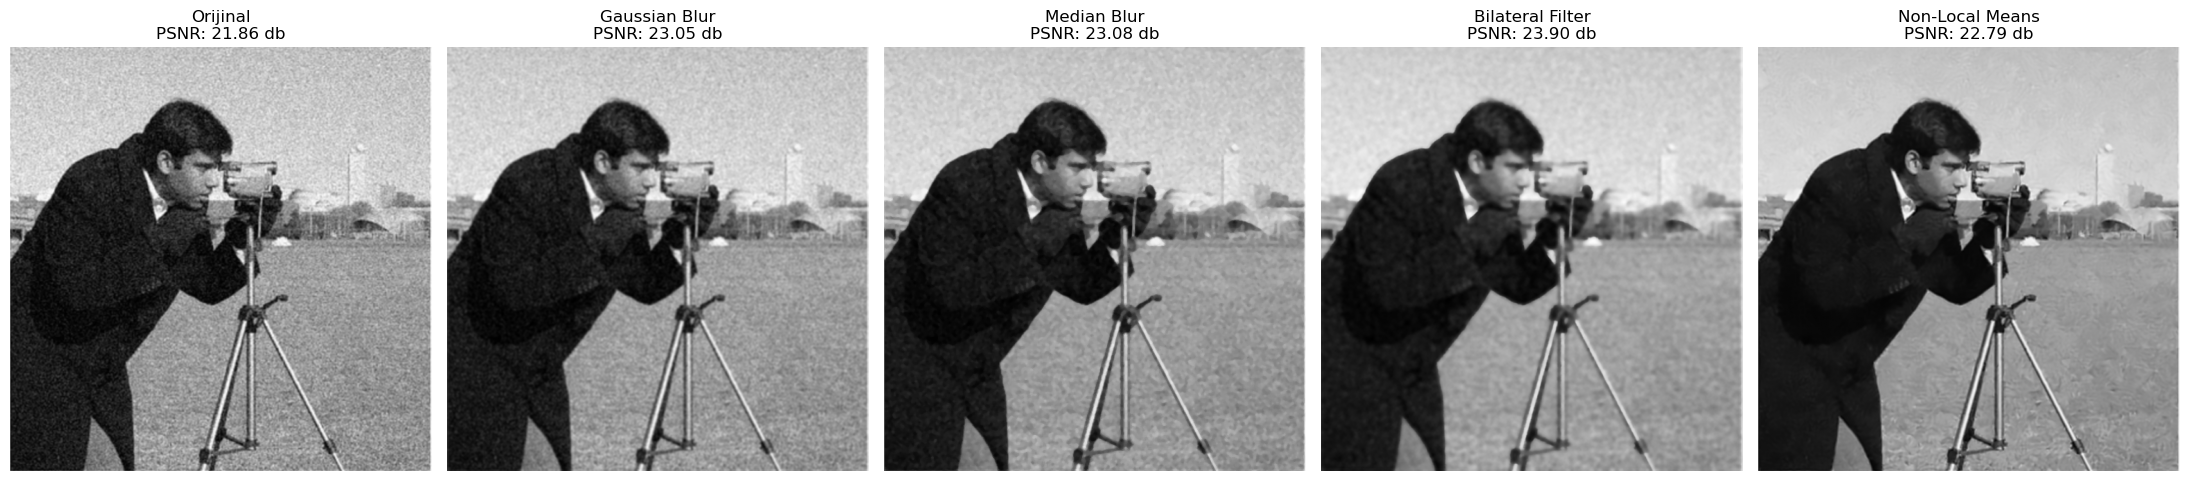

In [13]:
fig,axes=plt.subplots(1,5,figsize=(22,5))

for ax, (isim,img) in zip(axes,yontemler.items()):
    ax.imshow(img,cmap="gray")
    p_val=psnr(gray_referans,img)
    ax.set_title(f"{isim}\nPSNR: {p_val:.2f} db")
    ax.axis("off")
    
plt.tight_layout()
plt.savefig("denoise_yontem_karsilastirma.png",dpi=150)
plt.show()

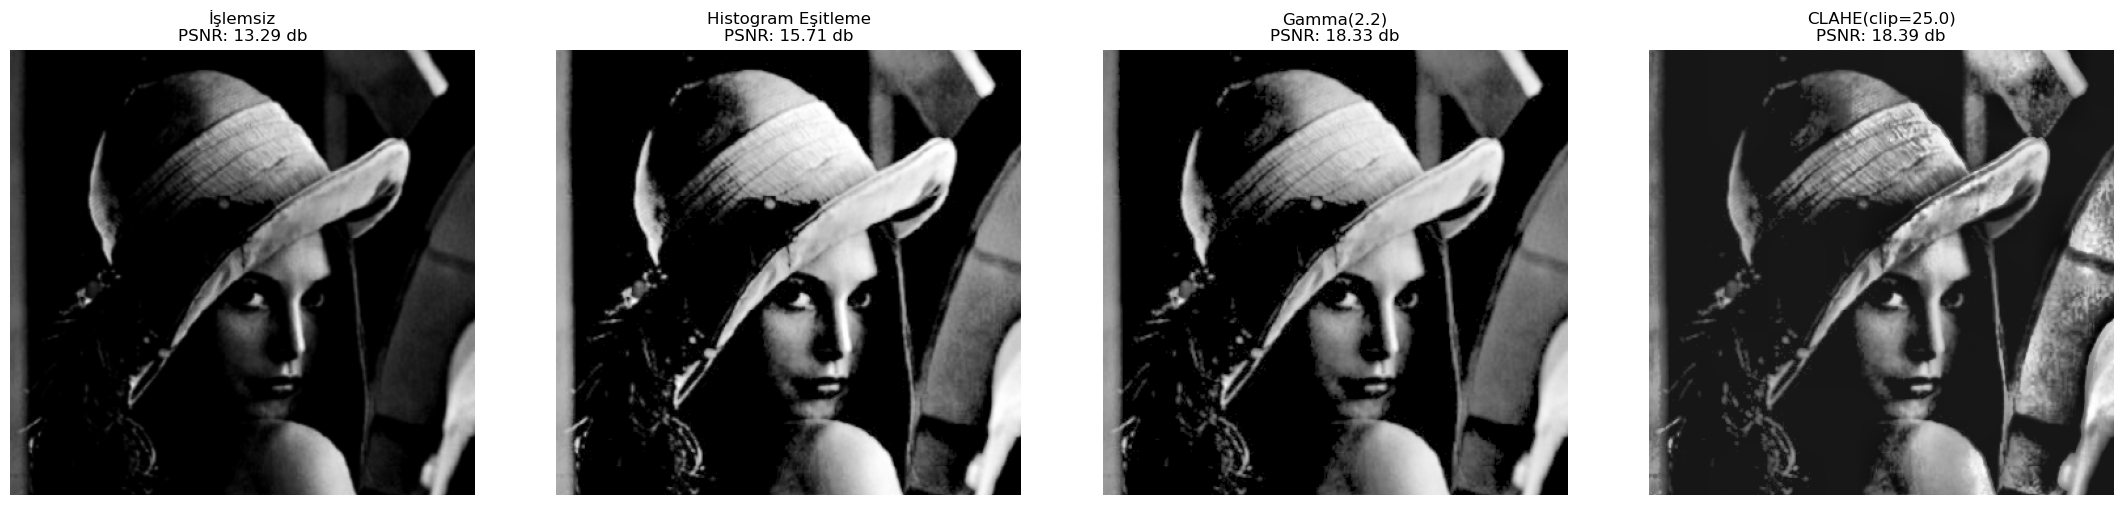

In [49]:
fig,axes=plt.subplots(1,4,figsize=(22,5))

for ax, (isim,img) in zip(axes,aday_yontemler.items()):
    ax.imshow(img,cmap="gray")
    p_val=psnr(gray_karanlik_ref,img)
    ax.set_title(f"{isim}\nPSNR: {p_val:.2f} db")
    ax.axis("off")
    
plt.tight_layout()
plt.savefig("karanlik_yontem_karsilastirma.png",dpi=150)
plt.show()


===== NLM h PARAMETRE OPTİMİZASYONU =====
  h      psnr
  3 21.885892
  5 22.181182
  7 22.513231
 10 22.791976
 13 22.952450
 16 23.087362
 20 23.237792
200 23.073381

 En iyi h değeri: 20 (PSNR: 23.24 dB)


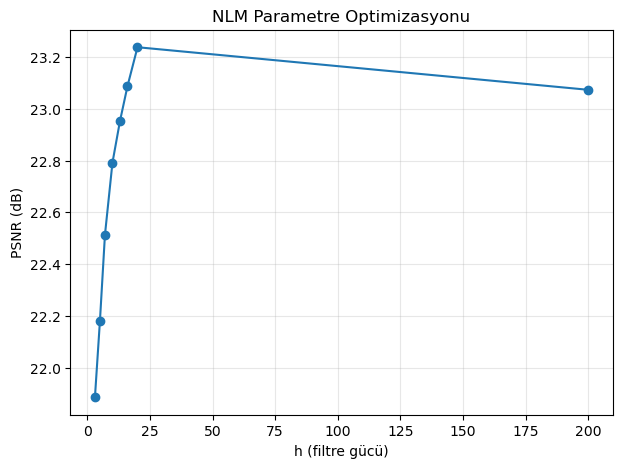

In [14]:
h_degerleri = [3, 5, 7, 10, 13, 16, 20,200]
grid_sonuclar = []

for h in h_degerleri:
    denenen = cv2.fastNlMeansDenoising(gray_gurultulu, None, h=h, 
                                         templateWindowSize=7, searchWindowSize=21)
    grid_sonuclar.append({"h": h, "psnr": psnr(gray_referans, denenen)})

df_grid = pd.DataFrame(grid_sonuclar)
print("\n===== NLM h PARAMETRE OPTİMİZASYONU =====")
print(df_grid.to_string(index=False))

en_iyi_h = df_grid.loc[df_grid["psnr"].idxmax(), "h"]
print(f"\n En iyi h değeri: {en_iyi_h} (PSNR: {df_grid['psnr'].max():.2f} dB)")

plt.figure(figsize=(7, 5))
plt.plot(df_grid["h"], df_grid["psnr"], marker="o")
plt.xlabel("h (filtre gücü)")
plt.ylabel("PSNR (dB)")
plt.title("NLM Parametre Optimizasyonu")
plt.grid(True, alpha=0.3)
plt.savefig("nlm_parametre_optimizasyon.png", dpi=150)
plt.show()

nlm_final = cv2.fastNlMeansDenoising(gray_gurultulu, None, h=int(en_iyi_h), 
                                       templateWindowSize=7, searchWindowSize=21)

In [15]:
def unsharp_mask(img, sigma=1.0, amount=1.5):
    bulanik = cv2.GaussianBlur(img, (0, 0), sigma)
    keskin = cv2.addWeighted(img, 1 + amount, bulanik, -amount, 0)
    return keskin

nlm_keskin = unsharp_mask(nlm_final, sigma=1.0, amount=1.0)

print("\n===== KESKİNLEŞTİRME ÖNCESİ/SONRASI =====")
print(f"Denoise (keskinleştirme öncesi) -> PSNR: {psnr(gray_referans, nlm_final):.2f} dB")
print(f"Denoise + Keskinleştirme        -> PSNR: {psnr(gray_referans, nlm_keskin):.2f} dB")
print(f"Denoise (öncesi)  -> Blur Score: {cv2.Laplacian(nlm_final, cv2.CV_64F).var():.2f}")
print(f"Denoise + Keskin  -> Blur Score: {cv2.Laplacian(nlm_keskin, cv2.CV_64F).var():.2f}")


===== KESKİNLEŞTİRME ÖNCESİ/SONRASI =====
Denoise (keskinleştirme öncesi) -> PSNR: 23.24 dB
Denoise + Keskinleştirme        -> PSNR: 22.67 dB
Denoise (öncesi)  -> Blur Score: 34.38
Denoise + Keskin  -> Blur Score: 71.10


In [16]:
import os; os.makedirs("ciktilar", exist_ok=True)
cv2.imwrite("ciktilar/gurultulu_foto_iyilestirilmis.png", nlm_keskin)

print("\n===== ÖZET: GÜRÜLTÜLÜ FOTO PIPELINE'I =====")
print(f"Ham gürültülü foto      -> PSNR: {baseline_psnr:.2f} dB, SSIM: {baseline_ssim:.4f}")
print(f"NLM (h={int(en_iyi_h)}) + Keskinleştirme -> PSNR: {psnr(gray_referans, nlm_keskin):.2f} dB, SSIM: {ssim(gray_referans, nlm_keskin):.4f}")


===== ÖZET: GÜRÜLTÜLÜ FOTO PIPELINE'I =====
Ham gürültülü foto      -> PSNR: 21.86 dB, SSIM: 0.4326
NLM (h=20) + Keskinleştirme -> PSNR: 22.67 dB, SSIM: 0.7314


In [21]:
img_karanlik_ref=cv2.imread("fotograflar/karanlik_referans.jpg")
gray_karanlik_ref=cv2.cvtColor(img_karanlik_ref,cv2.COLOR_BGR2GRAY)

if gray_karanlik_ref.shape != gray_karanlik2.shape:
    h=min(gray_karanlik_ref.shape[0],gray_karanlik2.shape[0])
    w=min(gray_karanlik_ref.shape[1],gray_karanlik2.shape[1])
    gray_karanlik_ref=cv2.resize(gray_karanlik_ref,(w,h))
    gray_karanlik2=cv2.resize(gray_karanlik2,(w,h))
    
baseline_psnr_k=psnr(gray_karanlik_ref,gray_karanlik2)
baseline_ssim_k=ssim(gray_karanlik_ref,gray_karanlik2)
print(f"İşlenmemiş karanlık foto -> PSNR: {baseline_psnr_k:.2f} dB, SSIM: {baseline_ssim_k:.4f}")

İşlenmemiş karanlık foto -> PSNR: 13.29 dB, SSIM: 0.2508


In [42]:
eq_test=cv2.equalizeHist(gray_karanlik2)
gamma_test=gamma_duzeltme(gray_karanlik2,gamma=2.2)
clahe_test=cv2.createCLAHE(clipLimit=25.0,tileGridSize=(8,8)).apply(gray_karanlik2)

aday_yontemler={
    "İşlemsiz":gray_karanlik2,
    "Histogram Eşitleme":eq_test,
    "Gamma(2.2)":gamma_test,
    "CLAHE(clip=25.0)":clahe_test,
}

sonuclar_k=[]
for isim, img in aday_yontemler.items():
    sonuclar_k.append({
        "yontem":isim,
        "psnr":psnr(gray_karanlik_ref,img),
        "ssim":ssim(gray_karanlik_ref,img),
        "gurultu":homojen_bolge_gurultusu(img,y1b,y2b,x1b,x2b)
    })
df_karanlik=pd.DataFrame(sonuclar_k)
print("\n===== KARANLIK FOTO: YÖNTEM KARŞILAŞTIRMASI (Referansa Göre) =====")
print(df_karanlik.to_string(index=False))



===== KARANLIK FOTO: YÖNTEM KARŞILAŞTIRMASI (Referansa Göre) =====
            yontem      psnr     ssim   gurultu
          İşlemsiz 13.291303 0.250822  5.424039
Histogram Eşitleme 15.710716 0.366134 28.681908
        Gamma(2.2) 18.325149 0.427138 21.934215
  CLAHE(clip=25.0) 18.387708 0.540681  9.056307



===== GAMMA OPTİMİZASYONU =====
 gamma      psnr     ssim
   1.2 14.350279 0.307039
   1.5 15.925930 0.371323
   1.8 17.242578 0.406929
   2.0 17.891337 0.419838
   2.2 18.325149 0.427138
   2.5 18.521979 0.429811
   2.8 18.301861 0.427506
   3.2 17.626842 0.419868

 En iyi gamma: 2.5 (PSNR: 18.52 dB)


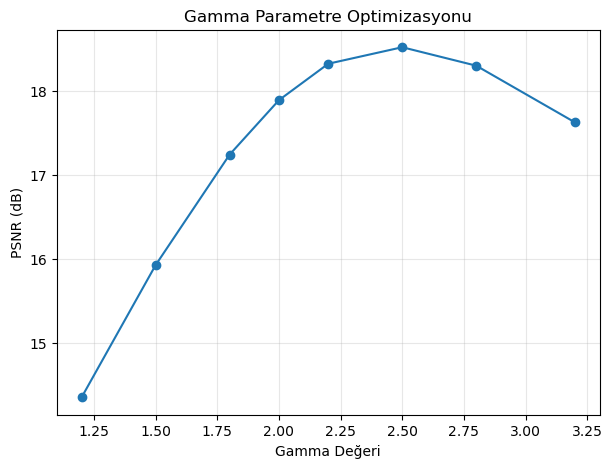

In [45]:
gamma_degerleri=[1.2,1.5,1.8,2.0,2.2,2.5,2.8,3.2]
grid_gamma=[]

for g in gamma_degerleri:
    denenen=gamma_duzeltme(gray_karanlik2,gamma=g)
    grid_gamma.append({"gamma":g,"psnr":psnr(gray_karanlik_ref,denenen),
                        "ssim":ssim(gray_karanlik_ref,denenen)})
df_gamma=pd.DataFrame(grid_gamma)
print("\n===== GAMMA OPTİMİZASYONU =====")
print(df_gamma.to_string(index=False))

en_iyi_gamma = df_gamma.loc[df_gamma["psnr"].idxmax(), "gamma"]
print(f"\n En iyi gamma: {en_iyi_gamma} (PSNR: {df_gamma['psnr'].max():.2f} dB)")

plt.figure(figsize=(7, 5))
plt.plot(df_gamma["gamma"], df_gamma["psnr"], marker="o", label="PSNR")
plt.xlabel("Gamma Değeri")
plt.ylabel("PSNR (dB)")
plt.title("Gamma Parametre Optimizasyonu")
plt.grid(True, alpha=0.3)
plt.savefig("gamma_optimizasyon.png", dpi=150)
plt.show()



===== CLAHE clipLimit OPTİMİZASYONU =====
 clipLimit      psnr     ssim
       5.0 17.597312 0.481265
      10.0 18.025718 0.510767
      15.0 18.173786 0.526836
      20.0 18.323089 0.536554
      25.0 18.387708 0.540681
      30.0 18.341937 0.542482
      40.0 17.888336 0.537463

 En iyi clipLimit: 25.0 (PSNR: 18.39 dB)


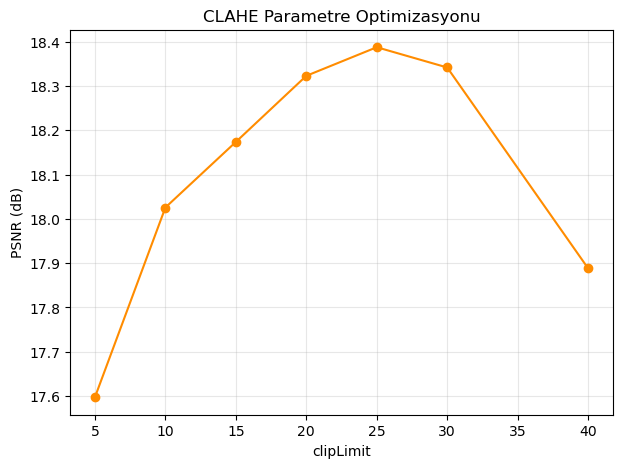

In [46]:
clip_degerleri=[5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0]
grid_clahe=[]

for c in clip_degerleri:
    clahe_obj=cv2.createCLAHE(clipLimit=c,tileGridSize=(8,8))
    denenen=clahe_obj.apply(gray_karanlik2)
    grid_clahe.append({"clipLimit":c,"psnr":psnr(gray_karanlik_ref,denenen),
                        "ssim":ssim(gray_karanlik_ref,denenen)})
    
df_clahe = pd.DataFrame(grid_clahe)
print("\n===== CLAHE clipLimit OPTİMİZASYONU =====")
print(df_clahe.to_string(index=False))

en_iyi_clip = df_clahe.loc[df_clahe["psnr"].idxmax(), "clipLimit"]
print(f"\n En iyi clipLimit: {en_iyi_clip} (PSNR: {df_clahe['psnr'].max():.2f} dB)")

plt.figure(figsize=(7, 5))
plt.plot(df_clahe["clipLimit"], df_clahe["psnr"], marker="o", color="darkorange")
plt.xlabel("clipLimit")
plt.ylabel("PSNR (dB)")
plt.title("CLAHE Parametre Optimizasyonu")
plt.grid(True, alpha=0.3)
plt.savefig("clahe_optimizasyon.png", dpi=150)
plt.show()

In [47]:
en_iyi_clahe_obj=cv2.createCLAHE(clipLimit=en_iyi_clip,tileGridSize=(8,8))

sira_a = cv2.fastNlMeansDenoising(en_iyi_clahe_obj.apply(gray_karanlik2), None, h=7)
sira_b = en_iyi_clahe_obj.apply(cv2.fastNlMeansDenoising(gray_karanlik2, None, h=7))

print("\n===== SIRALAMA TESTİ =====")
print(f"Sadece CLAHE (sıralama yok)     -> PSNR: {psnr(gray_karanlik_ref, en_iyi_clahe_obj.apply(gray_karanlik2)):.2f} dB")
print(f"Sıra A (CLAHE -> Denoise)        -> PSNR: {psnr(gray_karanlik_ref, sira_a):.2f} dB")
print(f"Sıra B (Denoise -> CLAHE)        -> PSNR: {psnr(gray_karanlik_ref, sira_b):.2f} dB")


===== SIRALAMA TESTİ =====
Sadece CLAHE (sıralama yok)     -> PSNR: 18.39 dB
Sıra A (CLAHE -> Denoise)        -> PSNR: 18.43 dB
Sıra B (Denoise -> CLAHE)        -> PSNR: 18.23 dB


In [48]:
final_karanlik= sira_b if psnr(gray_karanlik_ref,sira_b) > psnr(gray_karanlik_ref,sira_a) else sira_a

cv2.imwrite("ciktilar/karanlik_foto_iyilestirilmis.png", final_karanlik)

print("\n===== ÖZET: KARANLIK FOTO PIPELINE'I =====")
print(f"Ham karanlık foto           -> PSNR: {baseline_psnr_k:.2f} dB, SSIM: {baseline_ssim_k:.4f}")
print(f"Final pipeline (gamma={en_iyi_gamma}, clip={en_iyi_clip}) -> PSNR: {psnr(gray_karanlik_ref, final_karanlik):.2f} dB, SSIM: {ssim(gray_karanlik_ref, final_karanlik):.4f}")


===== ÖZET: KARANLIK FOTO PIPELINE'I =====
Ham karanlık foto           -> PSNR: 13.29 dB, SSIM: 0.2508
Final pipeline (gamma=2.5, clip=25.0) -> PSNR: 18.43 dB, SSIM: 0.5548
